In this reading assignment, you will learn about the concepts of Batch Normalisation technique for normalising data on a neural network.

## Prerequisites:
To start with Batch Normalisation, you must have knowledge about:
- Concepts of mean, variance, batches

## Learning Objectives:
By the end of the lesson, all learners will be able to (minimum expected from everyone) :
- Recollect the importance of scaling a value between certain range
- Explain batch normalisation technique used to squeeze value between certain range
- Mathematical implementation of batch normalisation techniques


## Extending the concept of normalization
In the normalization part, we saw how normalizing the input values would enable us to use higher learning rate.
Consider a network with normalized input.

<center>
<figure>



<p>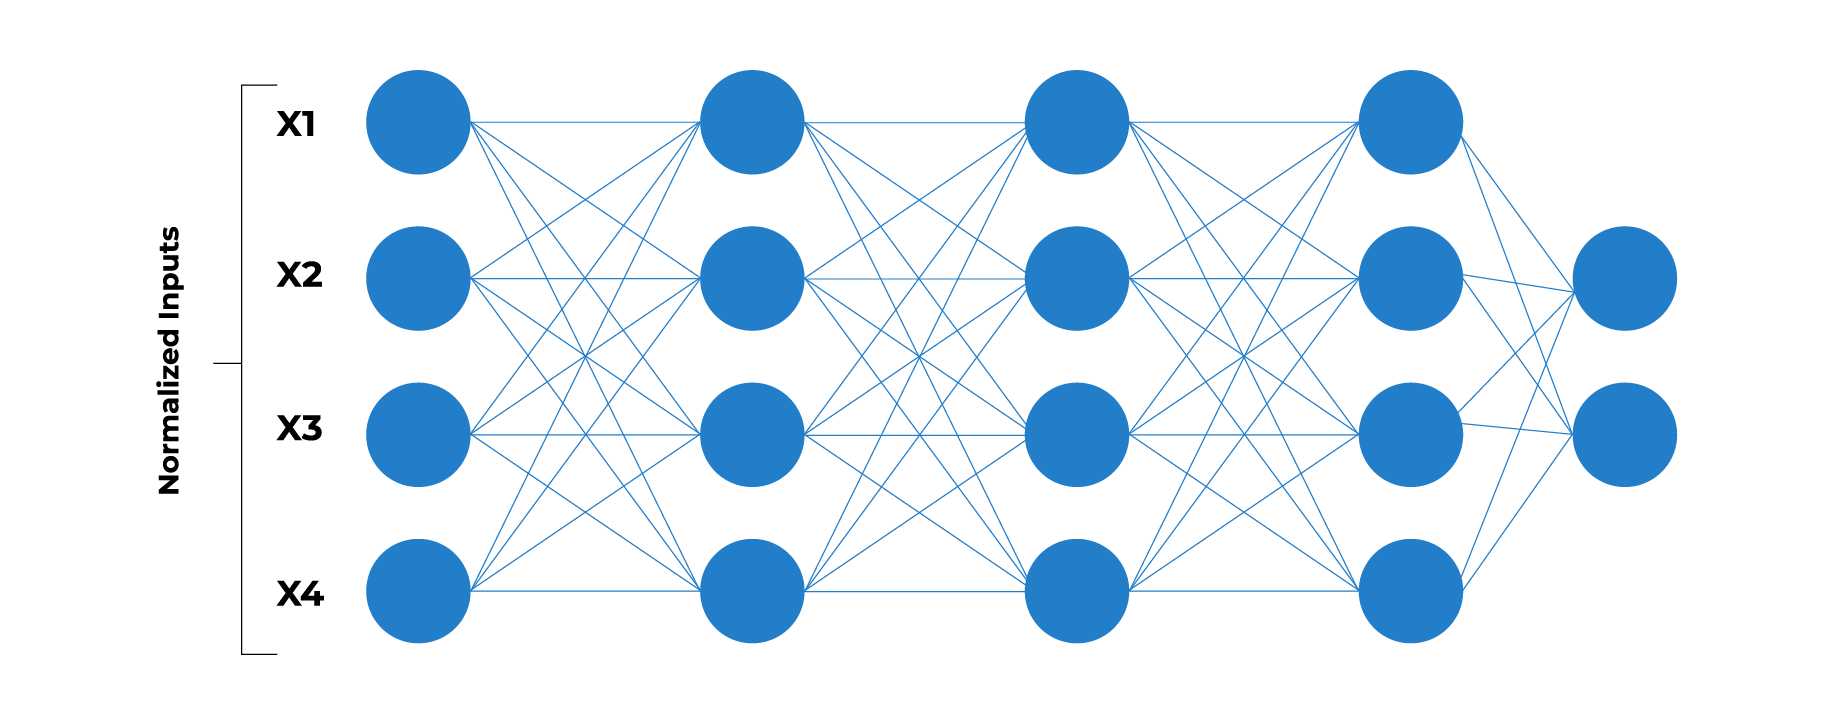</p>
<figcaption align="center">Figure 1: Normalized Input</figcaption>
</center>
</figure>
The output of the first layer constitutes an activation to the second layer and so on. Consider the value of some neurons in the hidden layer is exceptionally large. This causes the successive neurons depending on it to have a large value, thus causing the training process to be unstable and hence, decreasing the convergence rate.
<center>
<figure>


<p>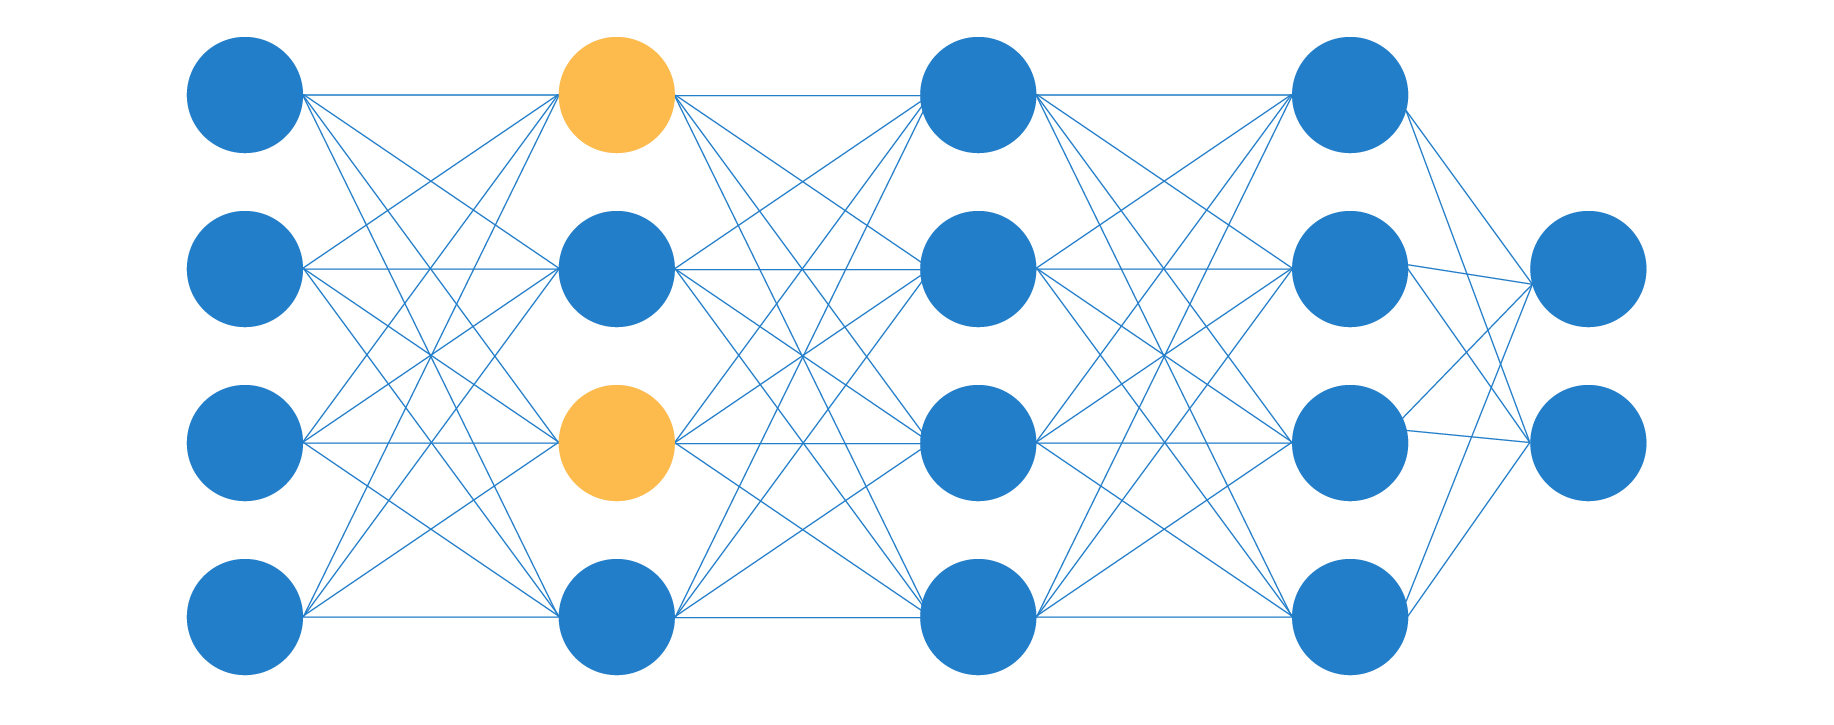</p>
  <figcaption align="center">Figure 2: Normalized Input</figcaption>
</center>
</figure>

  In the above figure, the dark yellow color represents neurons with exceptionally high value.

  What might be the solution to this problem?
  Well, the solution is simple, let's normalize the activation (input) to the next layer too. This will solve the problem of the instability of the training process. So we normalize the activations through the network.

  Based on the normalization technique, there are two strategies of normalizing the activations: batch normalization and layer normalization. We will discuss the batch normalization on the following section.

## Batch Normalization

To understand the concept of batch normalization, let's understand the concept of Internal Covariate Shift. The Internal Covariate shift refers to the change in the distribution of the input values to the model. If the training and testing data (for e.g image) comes from a different source (e.g from iPhone or DSLR) the distribution would differ. So change in the covariate shift can be a problem because the machine learning algorithm can change when the input distribution changes. The basic idea behind batch normalization is to limit the covariate shift by normalizing the activation of each layer.

Batch normalization is a normalization technique in which the output of each neuron in each hidden layer is normalized according to samples in a mini-batch. This reduces the amount that the values of the hidden layer shift around.
<center>
<figure>


<p>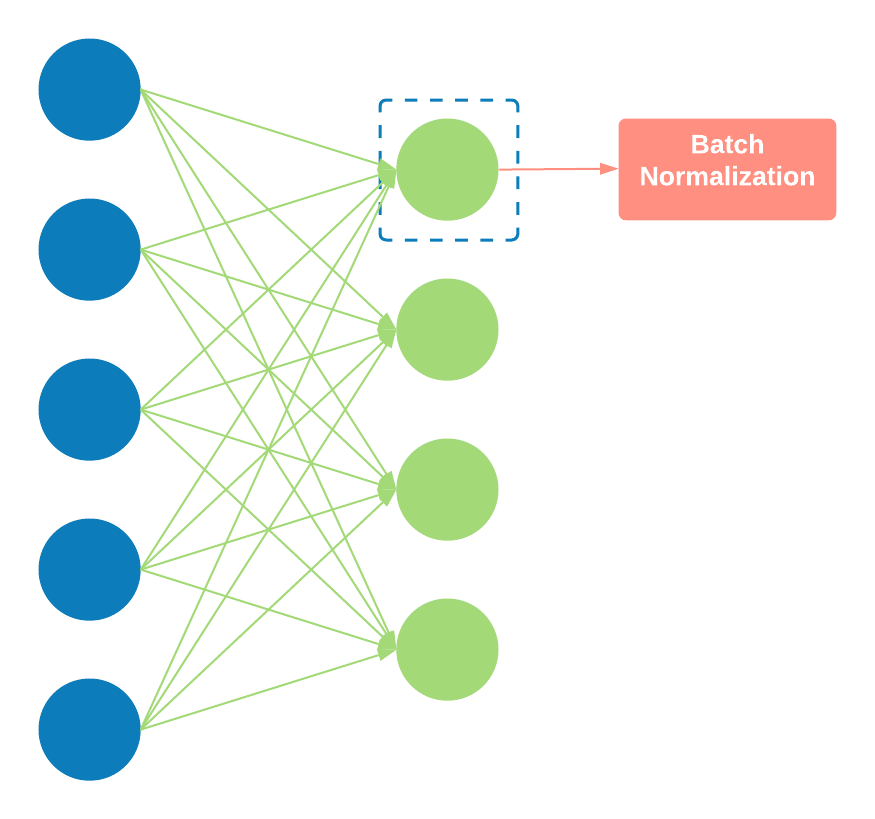</p>
<figcaption align="center">Figure 3: Batch Normalization</figcaption>
</figure>
</center>

The standardized value of input as previously disussed in standardization is
$$x_{scaled}=\frac{x-\mu}{\sigma}$$

In batch normalization, the mean($\mu$) and standard deviation($\sigma$) are computed in a mini-batch level (from samples in a batch). Then each of the neurons is normalized for each batch of samples. So we normalize each feature (each neuron) in a layer according to the batch of samples using calculated mean and standard deviation across a mini-batch of samples.

Consider a part of the network showing how we can normalize a neuron in the output layer for a batch size of 3.
When the samples are fed to the network, each neuron has an output for each input sample (here 3 output values in each batch).





<p>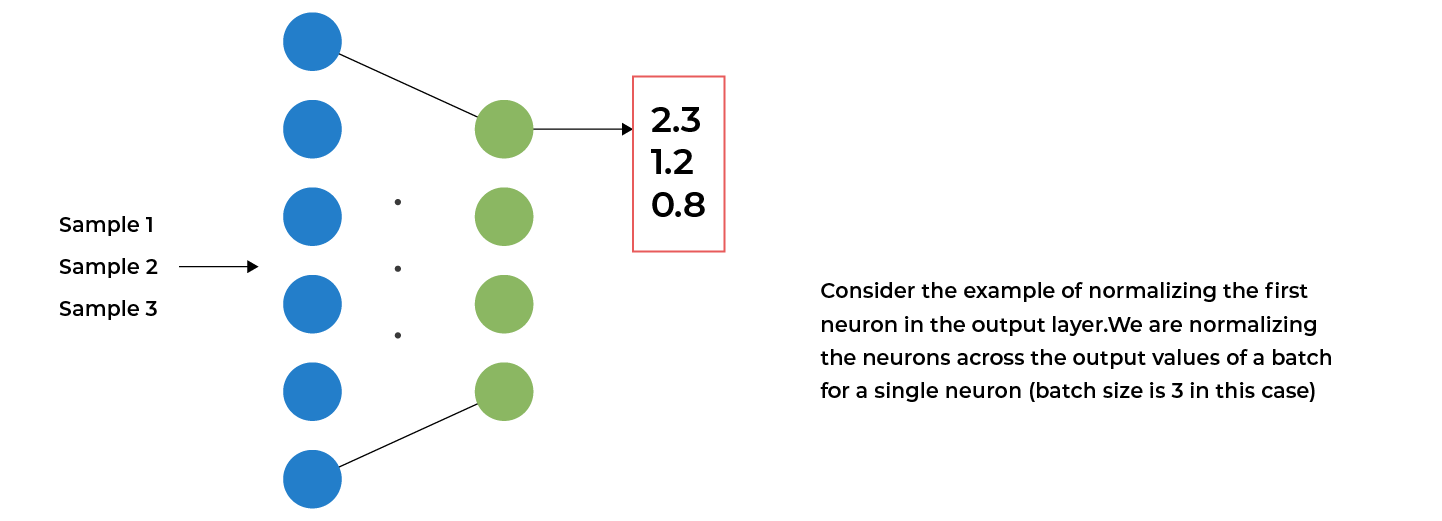</p>
 <figcaption align="center">Figure 4: batch norm with data</figcaption>



For each mini-batch of data (as shown in the red box), the mean and standard deviation is computed and then normalized accordingly. After that scaling and shifting of the normalized value take place by learnable parameters since the distribution normalized to standard distribution may not always be suitable. So along with normalization, we are also learning the best distribution for the data.

**Let's see the algorithm.**

$Input$ : Values of $x$ over a mini-batch: $B$= { $x_{1...m}$};

Parameters to be learned: $\gamma, \beta$

$Output $: $$ \{y_i=BN_{\gamma,\beta}(x_i) \} $$

$$\mu_{B}=\frac{1}{m}\sum_{i=1}^{m}x_i$$   
$$\sigma_B^2=\frac{1}{m}\sum_{i=1}^m(x_i-\mu_B)^2$$  
$$\hat{x_i}=\frac{x_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}$$

$$y_i=\gamma\hat{x_i}+\beta \equiv BN_{\gamma,\beta}(x_i)$$

where,

$x_i:$ Samples in a mini-batch

$m : $ The number of samples in a batch.

$\mu_B : $ Mini-batch mean

$\sigma_B : $ Mini-batch standard deviation

$\hat{x_i} : $ Normalized value.

$\gamma, \beta :$ Scaling and shifting parameters.

$\epsilon : $ Very small number to prevent division by zero.

<br>

<center>
<figure>


<p>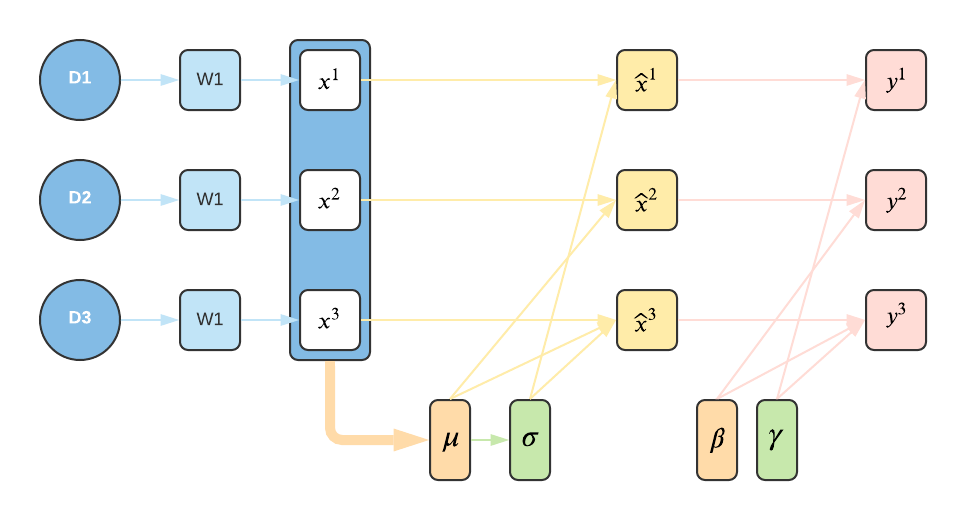</p>
<figcaption align="center">Figure 5: Batch Normalization at training time</figcaption>
</figure>
</center>


For the above case,

 $$\mu=\frac{2.3+1.2+0.8}{3} = 1.43 $$
 $$\sigma^2=0.96$$

For first data, i.e is 2.3

 $$\mu_{B}=\frac{1}{m}\sum_{i=1}^{m}x_i$$   
 $$\sigma_B^2=\frac{1}{m}\sum_{i=1}^m(x_i-\mu_B)^2$$   
 $$\hat{x_i}=\frac{x_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}$$

$$y_i=\gamma\hat{x_i}+\beta \equiv BN_{\gamma,\beta}(x_i)$$

 So the normalized  mini-batch (assuming $\epsilon=0.00001$) will be

 For first data, i.e is 2.3

 $$\hat{x_i}=\frac{2.3-1.43}{\sqrt{0.96+0.00001}} = 1.089$$

 Similarly,
 Other values are calculated as:

 $$\{ 1.089,-0.024,-0.433\}$$




We won't always normalize our value to have zero mean and unit variance. This would perform poorly for some activation functions (ex.Sigmoid). Thus we learn the best distribution by scaling our normalized value by $\gamma$ and shifting by $\beta$. If we set $\gamma$=1 and $\beta$=0, we will have standardization. We can even have batch normalization applied at a chosen layer only.

<br>



### Effect of batch normalization during test time
We have only single data at the testing time. so, at testing time to make prediction or evaluation of the network using batch normalization is we can't use mini-batches statistics like $\mu_B$ and $\sigma_B^2$ which can be meaning-less. The inputs to our activation functions will always be 0 since, we are normalizing them to have a mean of 0, and we will always get the same prediction, regardless of the input!

<center>
<figure>


<p>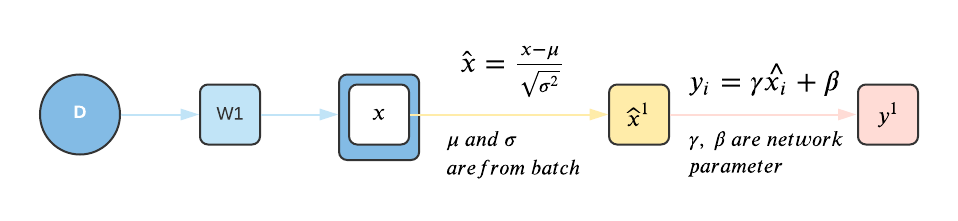</p>
<figcaption align="center">Figure 6: Batch Normalization at Testing time</figcaption>
</figure>
</center>


### Regularization effects of Batch Normalization

A training example in the dataset is input into the network within different mini-batches. The network cannot produce the deterministic values for the given example on every pass as each mini-batch is scaled and shifted by mean and variance computed on just that mini-batch. Thus, an example will be scaled and shifted by different amount at different time. Such variations act as noise to the hidden layer activations. Empirically, this phenomenon is found to be propitious to the generalization of the network.


**Benefits of batch normalization**
- It allows the network to converge faster since we are allowing the network to normalize the layer to whichever distribution is most optimal for learning.
- It allows the network to normalize into the distribution whichever is most optimal for learning.
- It also reduces the need for a bias for a layer since we are already shifting the normalized value with the $\beta$ parameter.


**Limitation of batch normalization**
- A fixed depth feed-forward neural network can store the running averages of the required statistics for inference in each layer easily. But, for Recurrent Neural Network(RNN) the running averages vary with the length of the sequences. Applying batch normalization to RNN requires memory for different statistics at different time steps. Additionally, if an inference sequence is longer than the training sequences, we will lack normalization parameters for spare time steps.
- Online learning tasks work with one observation at a time. Such cases cannot leverage batch normalization.
- In any case where mini-batches become very small batch normalization, performs poorly because the estimation of population statistics becomes very poor. We can say, batch normalization constraints the mini-batch size.


# Implementation of Batch Normalization in Tensorflow


In [ ]:
# Import the required libraries
import tensorflow as tf
from keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization

In [ ]:
# Set Hyperparameter
Epochs = 20
batch_size = 250
classes = 10
validation_spilt = 0.1

In [ ]:
# Data Preprocessing

# Load MNIST data
(X_train,y_train),(X_test,y_test) = mnist.load_data()

#Shape of input shape
X_train_shape = X_train.shape
X_test_shape = X_test.shape

# Keras Input shape
input_shape = (X_train_shape[1],X_train_shape[2])

# Parse number as floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalize data
X_train = X_train/255
X_test = X_test/255

11493376/11490434 [==============================] - 0s 0us/step


In [ ]:
# Building a model without BatchNormalization
model = Sequential([
      Flatten(input_shape = input_shape),
      Dense(units=128,activation='relu'),
      Dense(units=classes,activation='softmax')
])

# Complie the model
model.compile(optimizer='sgd',loss='SparseCategoricalCrossentropy',metrics=['accuracy'])

#Fit data to model
history = model.fit(X_train,y_train,epochs=Epochs,batch_size=batch_size,validation_split=validation_spilt)

Epoch 1/20
216/216 [==============================] - 1s 5ms/step - loss: 1.5750 - accuracy: 0.6278 - val_loss: 1.0075 - val_accuracy: 0.8278
Epoch 2/20
216/216 [==============================] - 1s 5ms/step - loss: 0.8534 - accuracy: 0.8206 - val_loss: 0.6334 - val_accuracy: 0.8727
Epoch 3/20
216/216 [==============================] - 1s 5ms/step - loss: 0.6291 - accuracy: 0.8529 - val_loss: 0.4950 - val_accuracy: 0.8892
Epoch 4/20
216/216 [==============================] - 1s 5ms/step - loss: 0.5311 - accuracy: 0.8678 - val_loss: 0.4259 - val_accuracy: 0.8960
Epoch 5/20
216/216 [==============================] - 1s 5ms/step - loss: 0.4760 - accuracy: 0.8774 - val_loss: 0.3845 - val_accuracy: 0.9047
Epoch 6/20
216/216 [==============================] - 1s 5ms/step - loss: 0.4401 - accuracy: 0.8839 - val_loss: 0.3572 - val_accuracy: 0.9098
Epoch 7/20
216/216 [==============================] - 1s 5ms/step - loss: 0.4144 - accuracy: 0.8894 - val_loss: 0.3371 - val_accuracy: 0.9140
Epoch 

In [ ]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.2810 - accuracy: 0.9214


[0.2810264229774475, 0.9214000105857849]

In [ ]:
# Building a model with BatchNormalization
model = Sequential([
      Flatten(input_shape = input_shape),
      Dense(units=128,activation='relu'),
      # Define Batch Normalization
      BatchNormalization(),
      Dense(units=classes,activation='softmax')
])

# Complie the model
model.compile(optimizer='sgd',loss='SparseCategoricalCrossentropy',metrics=['accuracy'])

#Fit data to model
history_bn = model.fit(X_train,y_train,epochs=Epochs,batch_size=batch_size,validation_split=validation_spilt)

Epoch 1/20
216/216 [==============================] - 1s 6ms/step - loss: 0.8004 - accuracy: 0.7604 - val_loss: 0.6230 - val_accuracy: 0.8938
Epoch 2/20
216/216 [==============================] - 1s 5ms/step - loss: 0.3907 - accuracy: 0.8926 - val_loss: 0.3088 - val_accuracy: 0.9258
Epoch 3/20
216/216 [==============================] - 1s 6ms/step - loss: 0.3203 - accuracy: 0.9123 - val_loss: 0.2431 - val_accuracy: 0.9383
Epoch 4/20
216/216 [==============================] - 1s 5ms/step - loss: 0.2813 - accuracy: 0.9229 - val_loss: 0.2156 - val_accuracy: 0.9417
Epoch 5/20
216/216 [==============================] - 1s 5ms/step - loss: 0.2543 - accuracy: 0.9301 - val_loss: 0.1977 - val_accuracy: 0.9470
Epoch 6/20
216/216 [==============================] - 1s 5ms/step - loss: 0.2343 - accuracy: 0.9356 - val_loss: 0.1845 - val_accuracy: 0.9517
Epoch 7/20
216/216 [==============================] - 1s 5ms/step - loss: 0.2188 - accuracy: 0.9396 - val_loss: 0.1734 - val_accuracy: 0.9542
Epoch 

In [ ]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.1362 - accuracy: 0.9627


[0.13615137338638306, 0.9627000093460083]

In [ ]:
model.predict_classes(X_test)

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


array([7, 2, 1, ..., 4, 5, 6])

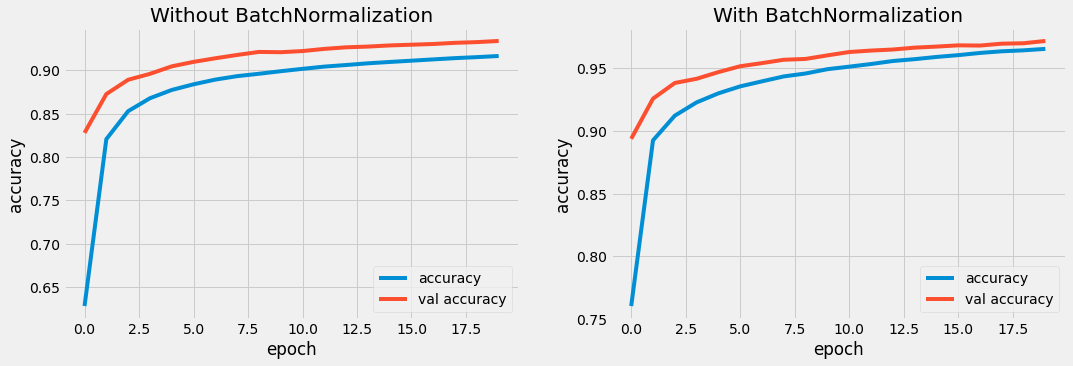

In [ ]:
# compare the accuracy plots of both the training.
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
fig,(ax1,ax2) = plt.subplots(ncols=2,nrows=1,figsize=(16,5))
ax1.plot(history.history['accuracy'],label='accuracy')
ax1.plot(history.history['val_accuracy'],label='val accuracy')
ax2.plot(history_bn.history['accuracy'],label='accuracy')
ax2.plot(history_bn.history['val_accuracy'],label='val accuracy')
ax1.set_title('Without BatchNormalization')
ax2.set_title('With BatchNormalization')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.set_xlabel('epoch')
ax1.legend()
ax2.legend()

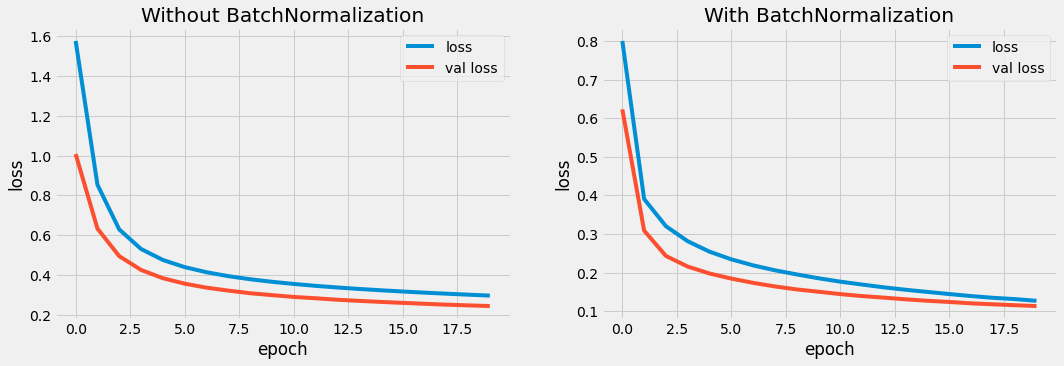

In [ ]:
# compare the loss plots of both the training.
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
fig,(ax1,ax2) = plt.subplots(ncols=2,nrows=1,figsize=(16,5))
ax1.plot(history.history['loss'],label='loss')
ax1.plot(history.history['val_loss'],label='val loss')
ax2.plot(history_bn.history['loss'],label='loss')
ax2.plot(history_bn.history['val_loss'],label='val loss')
ax1.set_title('Without BatchNormalization')
ax2.set_title('With BatchNormalization')
ax1.set_ylabel('loss')
ax1.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax1.legend()
ax2.legend()

# Implementation of Batch Normalization in PyTorch


In [ ]:
# Import the required libraries
import torch
from torch import nn
import torch.nn.functional as F

In [ ]:
# Data Preprocessing
from torchvision import datasets
from torchvision.transforms import ToTensor

# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), # Read file and convert image to Tensor
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [ ]:
# set data parameter
import numpy as np
classes = len(training_data.classes)
input_size=np.prod(training_data[0][0].shape[-2:])
batch_size = 250

In [ ]:
from torch.utils.data import DataLoader

# we shuffle during training only
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [ ]:
def train(dataloader, model, loss_func, optimizer):
    num_examples = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Put model in training mode
    model.train()

    # Initialize variable to store epoch loss and accuracy
    epoch_loss = 0
    epoch_correct = 0

    # Loops over the training data on batch
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction error
        pred = model(X)
        loss = loss_func(pred, y)

        # Remove any previous gradient calculation done by optimizer
        optimizer.zero_grad()

        # Perform backward propagation
        loss.backward()

        # Perform gradient update
        optimizer.step()

        # Calculate accuracy
        epoch_correct += (pred.argmax(dim=-1) == y).sum().item()
        epoch_loss += loss.item()

        # Log at every 100 steps of training
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{num_examples:>5d}]")

    # return epoch avg loss and accuracy
    return epoch_loss/num_batches, epoch_correct/num_examples

In [ ]:
def evaluate(dataloader, model, loss_func):
    num_examples = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Put model in evalutation mode
    model.eval()

    # Initialize variable to store loss and accuracy
    test_loss = 0
    test_correct = 0

    # disable gadient calculation during evaluation
    with torch.no_grad():
        # Loops over the evaluation data on batch
        for batch, (X, y) in enumerate(dataloader):
            # Compute prediction error
            pred = model(X)
            loss = loss_func(pred, y)

            # Calculate accuracy
            test_correct += (pred.argmax(dim=-1) == y).sum().item()
            test_loss += loss.item()

    # Eval metrics
    test_loss = test_loss/num_batches
    test_accuracy = test_correct/num_examples
    print(f"Val Metrics: Loss: {test_loss}, Accuracy: {test_accuracy}")
    # return avg loss and accuracy
    return test_loss, test_accuracy

In [ ]:
# Building a model without BatchNormalization
model = nn.Sequential(
      nn.Flatten(),
      nn.Linear(input_size, 128),
      nn.ReLU(),
      nn.Linear(128, classes),
)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

epochs = 20
history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': [],
}
for ep in range(epochs):
    print(f"Epoch: {ep + 1}\n--------------------------------")
    train_loss, train_acc = train(train_dataloader, model, loss_func, optimizer)
    val_loss, val_acc = evaluate(test_dataloader, model, loss_func)

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

print("Training Complete")

Epoch: 1
--------------------------------
loss: 2.305578  [    0/60000]
loss: 0.551039  [25000/60000]
loss: 0.427342  [50000/60000]
Val Metrics: Loss: 0.5003048822283744, Accuracy: 0.8287
Epoch: 2
--------------------------------
loss: 0.447053  [    0/60000]
loss: 0.486271  [25000/60000]
loss: 0.385499  [50000/60000]
Val Metrics: Loss: 0.4487429790198803, Accuracy: 0.8421
Epoch: 3
--------------------------------
loss: 0.430204  [    0/60000]
loss: 0.409641  [25000/60000]
loss: 0.395454  [50000/60000]
Val Metrics: Loss: 0.4267572097480297, Accuracy: 0.8464
Epoch: 4
--------------------------------
loss: 0.396079  [    0/60000]
loss: 0.379276  [25000/60000]
loss: 0.312327  [50000/60000]
Val Metrics: Loss: 0.4049457013607025, Accuracy: 0.8594
Epoch: 5
--------------------------------
loss: 0.317941  [    0/60000]
loss: 0.314404  [25000/60000]
loss: 0.373751  [50000/60000]
Val Metrics: Loss: 0.3943448938429356, Accuracy: 0.8597
Epoch: 6
--------------------------------
loss: 0.311661  [ 

In [ ]:
# Building a model with BatchNormalization
model = nn.Sequential(
      nn.Flatten(),
      nn.Linear(input_size, 128),
      nn.ReLU(),
      # Define Batch Normalization
      nn.BatchNorm1d(128),
      nn.Linear(128, classes),
)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

epochs = 20
history_bn = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': [],
}
for ep in range(epochs):
    print(f"Epoch: {ep + 1}\n--------------------------------")
    train_loss, train_acc = train(train_dataloader, model, loss_func, optimizer)
    val_loss, val_acc = evaluate(test_dataloader, model, loss_func)

    history_bn['loss'].append(train_loss)
    history_bn['val_loss'].append(val_loss)
    history_bn['accuracy'].append(train_acc)
    history_bn['val_accuracy'].append(val_acc)

print("Training Complete")

Epoch: 1
--------------------------------
loss: 2.303106  [    0/60000]
loss: 0.429599  [25000/60000]
loss: 0.382994  [50000/60000]
Val Metrics: Loss: 0.45836304128170013, Accuracy: 0.8325
Epoch: 2
--------------------------------
loss: 0.311563  [    0/60000]
loss: 0.346783  [25000/60000]
loss: 0.355577  [50000/60000]
Val Metrics: Loss: 0.41859190836548804, Accuracy: 0.8483
Epoch: 3
--------------------------------
loss: 0.295579  [    0/60000]
loss: 0.307161  [25000/60000]
loss: 0.278079  [50000/60000]
Val Metrics: Loss: 0.3824005231261253, Accuracy: 0.8628
Epoch: 4
--------------------------------
loss: 0.345655  [    0/60000]
loss: 0.296867  [25000/60000]
loss: 0.320223  [50000/60000]
Val Metrics: Loss: 0.3916795805096626, Accuracy: 0.8546
Epoch: 5
--------------------------------
loss: 0.314155  [    0/60000]
loss: 0.279176  [25000/60000]
loss: 0.239793  [50000/60000]
Val Metrics: Loss: 0.38334413170814513, Accuracy: 0.8646
Epoch: 6
--------------------------------
loss: 0.287957 

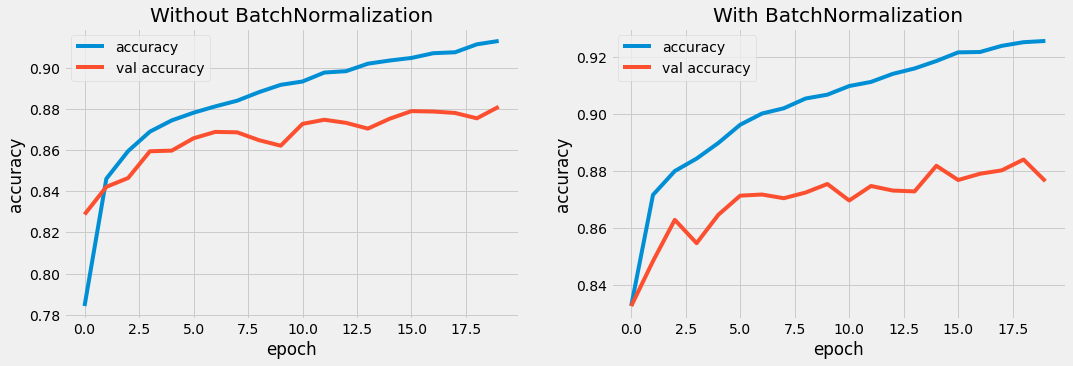

In [ ]:
# compare the accuracy plots of both the training.
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
fig,(ax1,ax2) = plt.subplots(ncols=2,nrows=1,figsize=(16,5))
ax1.plot(history['accuracy'],label='accuracy')
ax1.plot(history['val_accuracy'],label='val accuracy')
ax2.plot(history_bn['accuracy'],label='accuracy')
ax2.plot(history_bn['val_accuracy'],label='val accuracy')
ax1.set_title('Without BatchNormalization')
ax2.set_title('With BatchNormalization')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.set_xlabel('epoch')
ax1.legend()
ax2.legend()

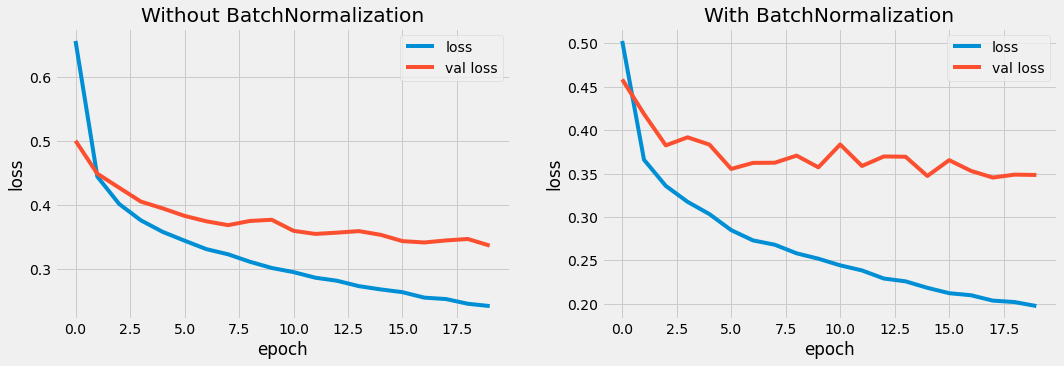

In [ ]:
# compare the loss plots of both the training.
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
fig,(ax1,ax2) = plt.subplots(ncols=2,nrows=1,figsize=(16,5))
ax1.plot(history['loss'],label='loss')
ax1.plot(history['val_loss'],label='val loss')
ax2.plot(history_bn['loss'],label='loss')
ax2.plot(history_bn['val_loss'],label='val loss')
ax1.set_title('Without BatchNormalization')
ax2.set_title('With BatchNormalization')
ax1.set_ylabel('loss')
ax1.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax1.legend()
ax2.legend()

From above plots, accuracy and convergence is better when we add batch normalization compare to without batch normalization. And also avoids overfitting. so, using batch normalization should always be consider while working with deep neural networks.


# Takeaways
The main takeaways from the lesson are:
- Batch Normalisation can mitigate the internal covariate shift for neural networks.
- Using the approach of mini batches, the mean and variance are calculated on a single mini batch but not of the whole layer.
- When the mini batches are too small, then the estimation of mean and variance on the mini batch could be a bad generalization.
- Accuracy and convergence is better when we add batch normalization


**Reference**

* Machine Learning Explained. 2020. An Intuitive Explanation Of Why Batch Normalization Really Works (Normalization In Deep Learning Part 1). [online] Available at: <http://mlexplained.com/2018/01/10/an-intuitive-explanation-of-why-batch-normalization-really-works-normalization-in-deep-learning-part-1/>

* Ioffe, S. and Szegedy, C., 2020. Batch Normalization: Accelerating Deep Network Training By Reducing Internal Covariate Shift. [online] arXiv.org. Available at: <https://arxiv.org/abs/1502.03167>.

* Ba, J., Kiros, J. and Hinton, G., 2020. Layer Normalization. [online] arXiv.org. Available at: <https://arxiv.org/abs/1607.06450>.
